# Preprocesamiento y entrenamiento

En este notebook se prepara el dataset local en formato YOLOv8, se unifican las clases del dataset y luego se entrenan modelos YOLO para la detección automática de capítulos de girasol.

In [2]:
# Importamos las librerías necesarias y configuramos rutas locales
import os
import shutil
import yaml
from pathlib import Path

import torch
from ultralytics import YOLO

print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA disponible: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [4]:
# Definimos la ruta local del dataset original descargado desde Roboflow

original_dataset_path = Path(r"C:\Users\feder\Documents\UBA\10 - Vision por Computadora II\TP\Sunflower-1")

print("Dataset original:")
print(original_dataset_path)

print("Existe:", original_dataset_path.exists())

Dataset original:
C:\Users\feder\Documents\UBA\10 - Vision por Computadora II\TP\Sunflower-1
Existe: True


In [5]:
# Verificamos la estructura del dataset original
os.listdir(original_dataset_path)

['data.yaml',
 'README.dataset.txt',
 'README.roboflow.txt',
 'test',
 'train',
 'valid']

In [6]:
# Consultamos cuánto ocupa el dataset original antes de clonarlo
total_size = 0

for dirpath, dirnames, filenames in os.walk(original_dataset_path):
    for filename in filenames:
        file_path = os.path.join(dirpath, filename)
        total_size += os.path.getsize(file_path)

print(f"Bytes: {total_size:,}")
print(f"MB: {total_size / (1024**2):.2f}")
print(f"GB: {total_size / (1024**3):.2f}")

Bytes: 357,783,095
MB: 341.21
GB: 0.33


### Clonación del dataset

In [7]:
# Definimos la ruta donde se guardará la copia unificada del dataset

unified_dataset_path = original_dataset_path.parent / "sunflower_unified"

print("Dataset unificado:")
print(unified_dataset_path)

Dataset unificado:
C:\Users\feder\Documents\UBA\10 - Vision por Computadora II\TP\sunflower_unified


In [8]:
# Creamos una copia del dataset original sólo si no existe

if not unified_dataset_path.exists():

    print("Creando dataset unificado...")

    shutil.copytree(
        original_dataset_path,
        unified_dataset_path
    )

else:
    print("El dataset unificado ya existe.")

El dataset unificado ya existe.


In [9]:
# Verificamos que la copia tenga la misma estructura que el dataset original
os.listdir(unified_dataset_path)

['data.yaml',
 'README.dataset.txt',
 'README.roboflow.txt',
 'test',
 'train',
 'valid']

### Unificación de clases

In [10]:
# Unificamos las clases del dataset: cualquier class_id pasa a ser 0
for split in ["train", "valid", "test"]:
    labels_dir = os.path.join(unified_dataset_path, split, "labels")

    for label_file in os.listdir(labels_dir):
        label_path = os.path.join(labels_dir, label_file)

        new_lines = []

        with open(label_path, "r") as file:
            lines = file.readlines()

        for line in lines:
            parts = line.strip().split()

            if len(parts) == 5:
                parts[0] = "0"
                new_lines.append(" ".join(parts))

        with open(label_path, "w") as file:
            file.write("\n".join(new_lines))

print("Clases unificadas correctamente.")

Clases unificadas correctamente.


In [11]:
# Actualizamos el archivo data.yaml para indicar que ahora existe una sola clase
yaml_path = os.path.join(unified_dataset_path, "data.yaml")

with open(yaml_path, "r") as file:
    data_yaml = yaml.safe_load(file)

data_yaml["nc"] = 1
data_yaml["names"] = ["sunflower"]

with open(yaml_path, "w") as file:
    yaml.dump(data_yaml, file, sort_keys=False)

print("data.yaml actualizado correctamente.")

data.yaml actualizado correctamente.


In [12]:
# Mostramos el contenido actualizado de data.yaml
with open(yaml_path, "r") as file:
    print(file.read())

names:
- sunflower
nc: 1
roboflow:
  license: CC BY 4.0
  project: sunflower-mn2cr
  url: https://universe.roboflow.com/raiyan8018/sunflower-mn2cr/dataset/1
  version: 1
  workspace: raiyan8018
test: ../test/images
train: ../train/images
val: ../valid/images



In [13]:
# Verificamos que todos los labels tengan únicamente class_id = 0
class_ids = set()

for split in ["train", "valid", "test"]:
    labels_dir = os.path.join(unified_dataset_path, split, "labels")

    for label_file in os.listdir(labels_dir):
        label_path = os.path.join(labels_dir, label_file)

        with open(label_path, "r") as file:
            for line in file:
                parts = line.strip().split()

                if len(parts) == 5:
                    class_id = int(parts[0])
                    class_ids.add(class_id)

print("Clases presentes después de unificar:")
print(class_ids)

Clases presentes después de unificar:
{0}


In [14]:
# Verificamos nuevamente cantidad de imágenes y labels en cada partición del dataset unificado
for split in ["train", "valid", "test"]:
    images_dir = os.path.join(unified_dataset_path, split, "images")
    labels_dir = os.path.join(unified_dataset_path, split, "labels")

    n_images = len(os.listdir(images_dir))
    n_labels = len(os.listdir(labels_dir))

    print(f"{split}: {n_images} imágenes | {n_labels} labels")

train: 3429 imágenes | 3429 labels
valid: 428 imágenes | 428 labels
test: 429 imágenes | 429 labels


In [15]:
print("Dataset unificado:", unified_dataset_path)
print("Data YAML:", unified_dataset_path / "data.yaml")

Dataset unificado: C:\Users\feder\Documents\UBA\10 - Vision por Computadora II\TP\sunflower_unified
Data YAML: C:\Users\feder\Documents\UBA\10 - Vision por Computadora II\TP\sunflower_unified\data.yaml


# Entrenamiento

### Training YOLOv8n Model

In [23]:
import os
import torch
from ultralytics import YOLO

# Verificación de hardware
device_to_use = 0 if torch.cuda.is_available() else "cpu"

print(f"Dispositivo asignado para entrenamiento: {device_to_use}")

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Corriendo en CPU.")

# Cargamos YOLOv8-Nano con pesos preentrenados en COCO
model_n = YOLO("yolov8n.pt")

# Entrenamiento baseline con YOLOv8n
metrics_n = model_n.train(
    data=str(unified_dataset_path / "data.yaml"),
    epochs=40,
    imgsz=640,
    batch=8,
    device=device_to_use,
    workers=0,
    cache=False,
    project="sunflower_counting",
    name="yolov8n_40e_local",
    save=True,
    plots=True
)

print("Entrenamiento YOLOv8n finalizado.")

Dispositivo asignado para entrenamiento: 0
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
New https://pypi.org/project/ultralytics/8.4.57 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.53  Python-3.11.15 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\feder\Documents\UBA\10 - Vision por Computadora II\TP\sunflower_unified\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, 

### Training YOLOv8s Model

In [24]:
import torch
from ultralytics import YOLO

# Verificacion de hardware para evitar ValueErrors
device_to_use = 0 if torch.cuda.is_available() else "cpu"
print(f"Dispositivo asignado para entrenamiento: {device_to_use}")

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Corriendo en CPU.")
    
# Cargamos la arquitectura YOLOv8-Small con pesos iniciales de COCO
model_s = YOLO("yolov8s.pt")

# Iniciamos el pipeline de fine-tuning sobre nuestra clase unificada
metrics_s = model_s.train(
    data=str(unified_dataset_path / "data.yaml"),
    epochs=40,
    imgsz=640,
    batch=4,
    device=device_to_use,
    workers=0,
    cache=False,
    project="sunflower_counting",
    name="yolov8s_40e_local",
    save=True,
    plots=True
)

print("Entrenamiento YOLOv8s finalizado.")

Dispositivo asignado para entrenamiento: 0
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
New https://pypi.org/project/ultralytics/8.4.57 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.53  Python-3.11.15 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\feder\Documents\UBA\10 - Vision por Computadora II\TP\sunflower_unified\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, 

### Training YOLOv8m Model

In [25]:
import os
import torch
from ultralytics import YOLO

# Verificación de hardware
device_to_use = 0 if torch.cuda.is_available() else "cpu"

print(f"Dispositivo asignado para entrenamiento: {device_to_use}")

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Corriendo en CPU.")

# Cargamos YOLOv8-Medium con pesos preentrenados en COCO
model_m = YOLO("yolov8m.pt")

# Entrenamiento baseline con YOLOv8m
metrics_m = model_m.train(
    data=str(unified_dataset_path / "data.yaml"),
    epochs=40,
    imgsz=640,
    batch=2,
    device=device_to_use,
    workers=0,
    cache=False,
    project="sunflower_counting",
    name="yolov8m_40e_local",
    save=True,
    plots=True
)

print("Entrenamiento YOLOv8m finalizado.")

Dispositivo asignado para entrenamiento: 0
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
New https://pypi.org/project/ultralytics/8.4.57 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.53  Python-3.11.15 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\feder\Documents\UBA\10 - Vision por Computadora II\TP\sunflower_unified\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, 

### Training YOLO11s con SGD



In [17]:
# Entrenamiento de YOLO11s con SGD durante 40 épocas
import os
import torch
from ultralytics import YOLO

# Verificación de hardware
device_to_use = 0 if torch.cuda.is_available() else "cpu"

print(f"Dispositivo asignado para entrenamiento: {device_to_use}")

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Corriendo en CPU.")
    
model_11s = YOLO("yolo11s.pt")

metrics_11s = model_11s.train(
    data=str(unified_dataset_path / "data.yaml"),
    epochs=40,
    imgsz=640,
    batch=4,
    device=device_to_use,
    workers=0,
    cache=False,
    optimizer="SGD",
    project="sunflower_counting",
    name="yolo11s_sgd_40e_local",
    save=True,
    plots=True
)

print("Entrenamiento YOLO11s con SGD finalizado.")

Dispositivo asignado para entrenamiento: 0
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
New https://pypi.org/project/ultralytics/8.4.57 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.53  Python-3.11.15 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\feder\Documents\UBA\10 - Vision por Computadora II\TP\sunflower_unified\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, 

## Comparación de Modelos YOLOv8 (n, s, m) y YOLO11s con SGD

In [26]:
#import os
#import pandas as pd

runs_dir = "runs/detect/sunflower_counting"

for run_name in os.listdir(runs_dir):
    results_path = os.path.join(runs_dir, run_name, "results.csv")
    print(run_name, "->", os.path.exists(results_path))

yolo11s_sgd_40e_local -> True
yolov8m_40e_local -> True
yolov8m_local_run1 -> True
yolov8n_40e_local -> True
yolov8n_local_run1 -> True
yolov8s_40e_local -> True
yolov8s_local_run1 -> True


In [27]:
import os
import pandas as pd

runs_dir = "runs/detect/sunflower_counting"

model_runs = {
    "YOLOv8n": os.path.join(runs_dir, "yolov8n_40e_local"),
    "YOLOv8s": os.path.join(runs_dir, "yolov8s_40e_local"),
    "YOLOv8m": os.path.join(runs_dir, "yolov8m_40e_local"),
    "YOLO11s SGD 40e": os.path.join(runs_dir, "yolo11s_sgd_40e_local")
}

all_results = []

for model_name, run_path in model_runs.items():

    results_csv_path = os.path.join(run_path, "results.csv")

    if os.path.exists(results_csv_path):

        df_results = pd.read_csv(results_csv_path)
        df_results.columns = df_results.columns.str.strip("# ")

        final_metrics = df_results.iloc[-1].to_dict()
        final_metrics["Model"] = model_name

        all_results.append(final_metrics)

    else:
        print(f"Warning: {results_csv_path} not found")

comparison_df = pd.DataFrame(all_results)

comparison_df[
    [
        "Model",
        "metrics/mAP50(B)",
        "metrics/mAP50-95(B)",
        "metrics/precision(B)",
        "metrics/recall(B)",
        "val/box_loss",
        "val/cls_loss",
        "val/dfl_loss"
    ]
]

,Model,metrics/mAP50(B),metrics/mAP50-95(B),metrics/precision(B),metrics/recall(B),val/box_loss,val/cls_loss,val/dfl_loss
0,YOLOv8n,0.90224,0.55996,0.86094,0.82996,1.18945,0.59102,0.94421
1,YOLOv8s,0.91081,0.56951,0.86616,0.83466,1.16534,0.55194,0.95179
2,YOLOv8m,0.91048,0.57037,0.86223,0.83706,1.16358,0.53312,0.99322
3,YOLO11s SGD 40e,0.90929,0.56996,0.86576,0.83278,1.17567,0.56404,0.94456


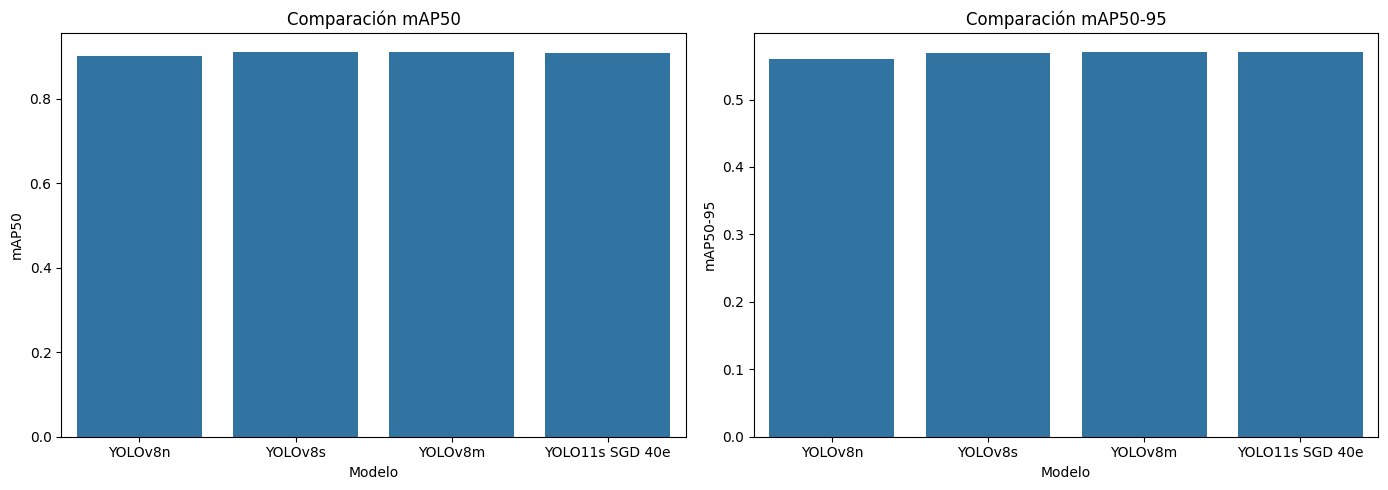

In [28]:
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    x="Model",
    y="metrics/mAP50(B)",
    data=comparison_df,
    ax=axes[0]
)

axes[0].set_title("Comparación mAP50")
axes[0].set_ylabel("mAP50")
axes[0].set_xlabel("Modelo")

sns.barplot(
    x="Model",
    y="metrics/mAP50-95(B)",
    data=comparison_df,
    ax=axes[1]
)

axes[1].set_title("Comparación mAP50-95")
axes[1].set_ylabel("mAP50-95")
axes[1].set_xlabel("Modelo")

plt.tight_layout()
plt.show()

**mAP50-95**

mAP50-95 (mean Average Precision) es la métrica principal utilizada para evaluar modelos de detección de objetos. Mide simultáneamente la capacidad del modelo para localizar correctamente los objetos y clasificarlos de manera adecuada.

El cálculo se realiza promediando la precisión obtenida para distintos umbrales de IoU (Intersection over Union), desde 0.50 hasta 0.95 con incrementos de 0.05. Por este motivo, es una métrica más exigente que mAP50, ya que requiere una mayor precisión en la ubicación de las bounding boxes.

Valores más altos indican un mejor desempeño global del detector.

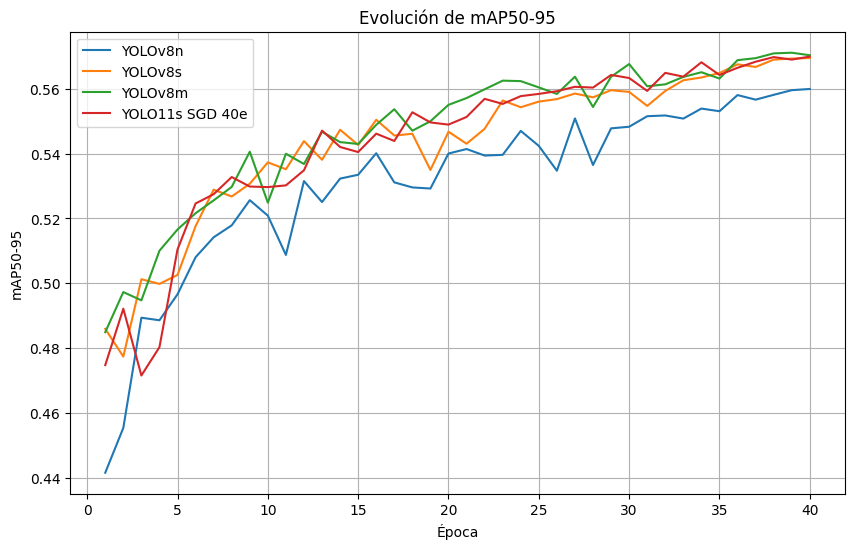

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import os

runs_dir = "runs/detect/sunflower_counting"

models = {
    "YOLOv8n": "yolov8n_40e_local",
    "YOLOv8s": "yolov8s_40e_local",
    "YOLOv8m": "yolov8m_40e_local",
    "YOLO11s SGD 40e": "yolo11s_sgd_40e_local"
}
plt.figure(figsize=(10,6))

for model_name, run_name in models.items():

    csv_path = os.path.join(
        runs_dir,
        run_name,
        "results.csv"
    )

    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip("# ")

    plt.plot(
        df["epoch"],
        df["metrics/mAP50-95(B)"],
        label=model_name
    )

plt.title("Evolución de mAP50-95")
plt.xlabel("Época")
plt.ylabel("mAP50-95")
plt.legend()
plt.grid(True)

plt.show()

**Box Loss**

Box Loss representa el error cometido por el modelo al estimar la posición y el tamaño de las bounding boxes respecto de las anotaciones reales del dataset.

Durante el entrenamiento, el objetivo es minimizar esta función de pérdida para que las cajas predichas coincidan lo mejor posible con las cajas reales. Por lo tanto, valores más bajos de Box Loss indican una mejor localización de los objetos detectados.

La evolución decreciente de esta métrica a lo largo de las épocas sugiere que el modelo está aprendiendo a ubicar con mayor precisión los capítulos de girasol presentes en las imágenes.

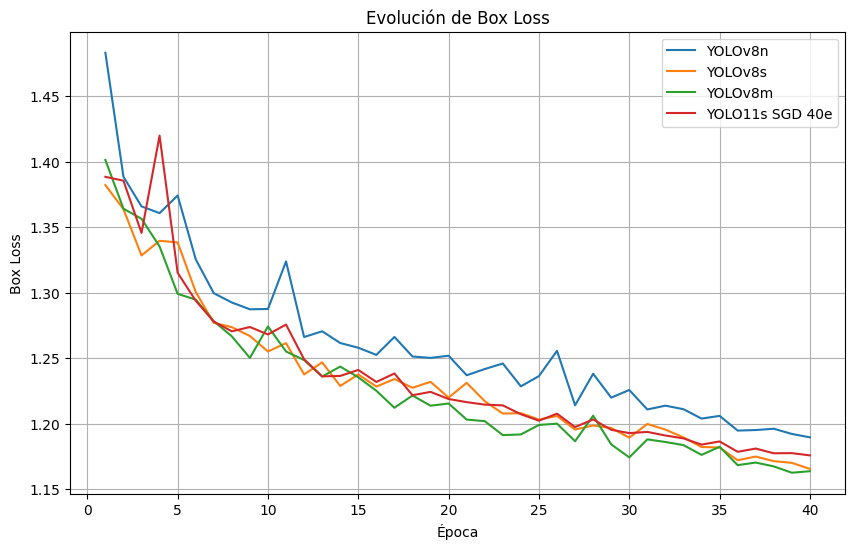

In [30]:
plt.figure(figsize=(10,6))

for model_name, run_name in models.items():

    csv_path = os.path.join(
        runs_dir,
        run_name,
        "results.csv"
    )

    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip("# ")

    plt.plot(
        df["epoch"],
        df["val/box_loss"],
        label=model_name
    )

plt.title("Evolución de Box Loss")
plt.xlabel("Época")
plt.ylabel("Box Loss")
plt.legend()
plt.grid(True)

plt.show()

### Selección del modelo

Aunque YOLOv8m obtuvo el mayor valor de mAP50-95, la diferencia respecto de YOLOv8s fue inferior al 0.1%, por lo que ambos modelos presentaron un rendimiento prácticamente equivalente.

Asimismo, se observó que el incremento en la cantidad de épocas tuvo un impacto significativamente mayor en el desempeño que el aumento de complejidad de la arquitectura, evidenciando que una estrategia de entrenamiento adecuada resulta más determinante que el uso de modelos de mayor tamaño.

Considerando el menor costo computacional de **YOLOv8s** y la similitud de resultados obtenidos, se seleccionó este modelo como **modelo final** del proyecto por ofrecer el mejor equilibrio entre precisión y eficiencia.
